# Melbourne Housing Price Prediction — Regression

## 1. Dataset Audit

This notebook develops regression models to predict property prices using the Melbourne Housing dataset.

The first stage is to understand the dataset structure, data types, missing values, duplicate records, and potential issues that need to be addressed before modeling.

In [366]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

Loading the dataset into the .ipynb file.

In [367]:
df = pd.read_csv(r'..\data\regression\Melbourne_housing.csv')
df.head()

C:\Users\gamin\AppData\Local\Temp\ipykernel_37060\3172911901.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'..\data\regression\Melbourne_housing.csv')


,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


## Dimensions of the Dataset



In [368]:
df.shape

(34857, 22)

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

## Descriptive Statistics of the dataset

These provide the information about the numerical attributes as well as categorical attributes in the dataset.

In [370]:
df.describe()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longtitude,Propertycount,Price
count,34857.000000,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,15551.000000,26881.000000,26881.000000,34854.000000,2.724700e+04
mean,3.031012,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,1965.289885,-37.810634,145.001851,7572.888306,1.050173e+06
std,0.969933,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,37.328178,0.090279,0.120169,4428.090313,6.414671e+05
min,1.000000,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.190430,144.423790,83.000000,8.500000e+04
25%,2.000000,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,1940.000000,-37.862950,144.933500,4385.000000,6.350000e+05
50%,3.000000,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,1970.000000,-37.807600,145.007800,6763.000000,8.700000e+05
75%,4.000000,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,2000.000000,-37.754100,145.071900,10412.000000,1.295000e+06
max,16.000000,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,2106.000000,-37.390200,145.526350,21650.000000,1.120000e+07


In [371]:
df.describe(include = 'object')

,Suburb,Address,Type,Method,SellerG,Date,BuildingArea,CouncilArea,Regionname,ParkingArea
count,34857,34857,34857,34857,34857,34857,13760,34854,34857,34857
unique,351,34009,3,9,388,78,994,33,8,8
top,Reservoir,5 Charles St,h,S,Jellis,28/10/2017,120,Boroondara City Council,Southern Metropolitan,Carport
freq,844,6,23980,19744,3359,1119,177,3675,11836,6243


### Missing Value Analysis

The dataset is checked for missing values in each feature. Both the number and percentage of missing observations are calculated to understand the extent of missing data and determine appropriate preprocessing strategies later.

In [372]:

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending = False)

print("Missing values in the dataset:\n", missing_values)

Missing values in the dataset:
 BuildingArea     21097
YearBuilt        19306
Landsize         11810
Car               8728
Bathroom          8226
Bedroom           8217
Latitude          7976
Longtitude        7976
Price             7610
CouncilArea          3
Propertycount        3
Distance             1
Postcode             1
dtype: int64


### Missing Value Percentage

The percentage of missing observations is calculated to assess the severity of missing data across different features.

In [373]:
missing_value_percentage = (df.isnull().sum() / len(df)) * 100

missing_value_percentage = missing_value_percentage[missing_value_percentage > 0].sort_values(ascending = False)
print("Percentage of missing values in the dataset:\n", missing_value_percentage)

Percentage of missing values in the dataset:
 BuildingArea     60.524428
YearBuilt        55.386293
Landsize         33.881286
Car              25.039447
Bathroom         23.599277
Bedroom          23.573457
Latitude         22.882061
Longtitude       22.882061
Price            21.832057
CouncilArea       0.008607
Propertycount     0.008607
Distance          0.002869
Postcode          0.002869
dtype: float64


### Missing Value Visualization

A bar chart is used to visualize the percentage of missing observations for features containing missing values.

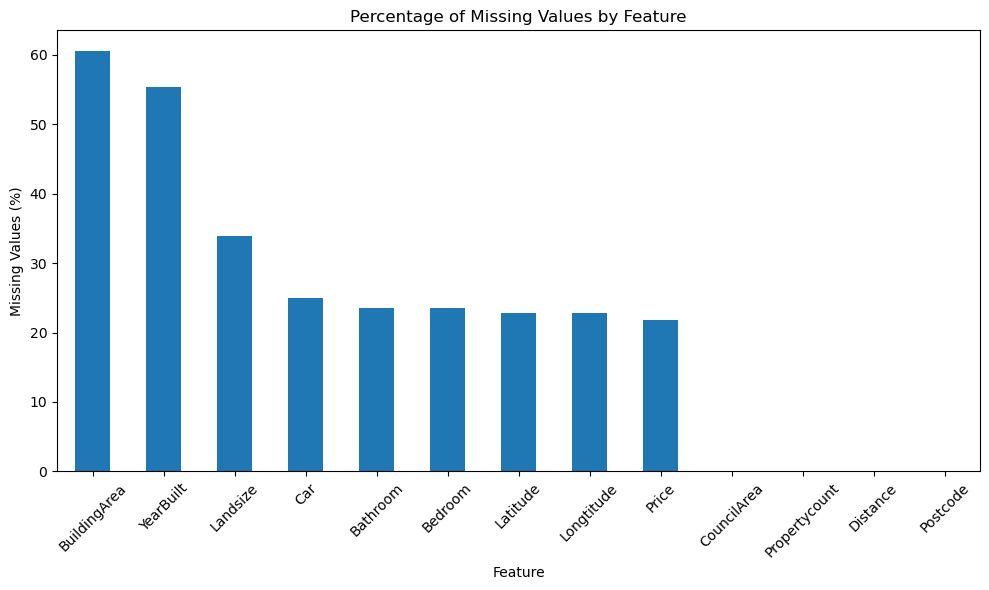

In [374]:
plt.figure(figsize=(10, 6))

missing_value_percentage.plot(kind="bar")

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Duplicate Record Analysis

The dataset is checked for completely duplicated rows to identify repeated observations.

In [375]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Data Type Analysis

The data types of all variables are inspected to identify numerical, categorical, date, and potentially malformed columns that require preprocessing.

In [376]:
df.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom          float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea      object
YearBuilt        float64
CouncilArea       object
Latitude         float64
Longtitude       float64
Regionname        object
Propertycount    float64
ParkingArea       object
Price            float64
dtype: object

### Cardinality Analysis

The number of unique values in each feature is examined to understand the cardinality of categorical variables and identify high-cardinality features that may require special treatment.

In [377]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Suburb: 351
Address: 34009
Rooms: 12
Type: 3
Method: 9
SellerG: 388
Date: 78
Distance: 215
Postcode: 211
Bedroom: 15
Bathroom: 11
Car: 15
Landsize: 1684
BuildingArea: 994
YearBuilt: 160
CouncilArea: 33
Latitude: 13402
Longtitude: 14524
Regionname: 8
Propertycount: 342
ParkingArea: 8
Price: 2871


### Investigation of BuildingArea

The BuildingArea feature is stored as an object rather than a numerical data type. Its values are inspected to determine the reason for the mixed data type and identify an appropriate cleaning strategy.

In [378]:
print("Data type:", df["BuildingArea"].dtype)

print("\nSample values:")
print(df["BuildingArea"].dropna().head(20))

Data type: object

Sample values:
0         inf
1         225
2          82
3         inf
4         122
5         263
6         inf
7         242
8         108
9         251
10        117
11    missing
12    missing
13         76
14        135
15    missing
16        399
17        inf
18        inf
19        inf
Name: BuildingArea, dtype: object


In [379]:
print("\nPython data types found:")
print(df["BuildingArea"].dropna().map(type).value_counts())


Python data types found:
BuildingArea
<class 'str'>      12930
<class 'float'>      830
Name: count, dtype: int64


In [380]:
print("\nSample unique values:")
print(df["BuildingArea"].dropna().unique()[:30])


Sample unique values:
['inf' '225' '82' '122' '263' '242' '108' '251' '117' 'missing' '76' '135'
 '399' '118' '103' '180' '123' '218' '129' '167' '154' '275' '121' '146'
 '125' '255' '94' '75' '254' '156']


### Target Variable Analysis

Price is the target variable for the regression task. Its data type, missing values, and descriptive statistics are examined before preprocessing.

In [381]:
print("Target variable: Price")
print("Data type:", df["Price"].dtype)
print("Missing values:", df["Price"].isnull().sum())

print("\nDescriptive statistics:")
print(df["Price"].describe())

Target variable: Price
Data type: float64
Missing values: 7610

Descriptive statistics:
count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64


## 2. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distributions, relationships, correlations, and potential anomalies within the Melbourne Housing dataset before applying preprocessing and machine learning models.

### 2.1 Target Variable Distribution

The distribution of the target variable, Price, is examined to understand its range, central tendency, and skewness.

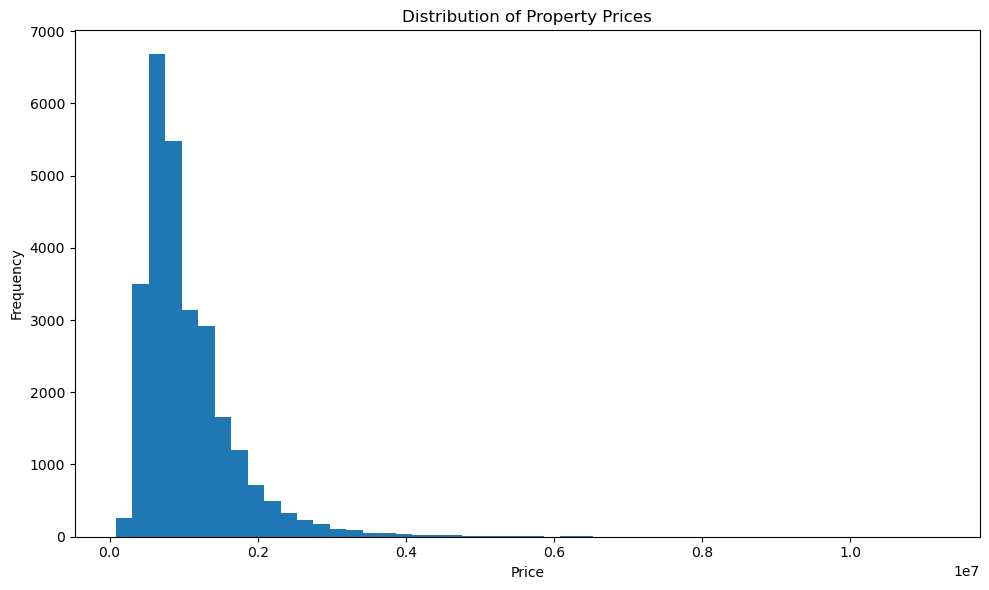

In [382]:
plt.figure(figsize=(10, 6))

plt.hist(df["Price"].dropna(), bins=50)

plt.title("Distribution of Property Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [383]:
df["Price"].describe()

count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64

### Insight Analysis


- The property price distribution is strongly right-skewed. Most properties are concentrated within the lower-to-middle price range, while a relatively small number of properties have substantially higher prices. These extreme values may have a strong influence on regression models and will therefore be investigated during the outlier analysis and preprocessing stage.

### 2.2 Numerical Feature Distributions

The distributions of numerical features are examined to identify their ranges, skewness, concentration, and potential unusual values.

In [384]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical features:")
print(list(numerical_columns))

Numerical features:
['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount', 'Price']


In [385]:
numerical_features = numerical_columns.drop("Price")

print("Number of numerical features:", len(numerical_features))
print(list(numerical_features))

Number of numerical features: 11
['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount']


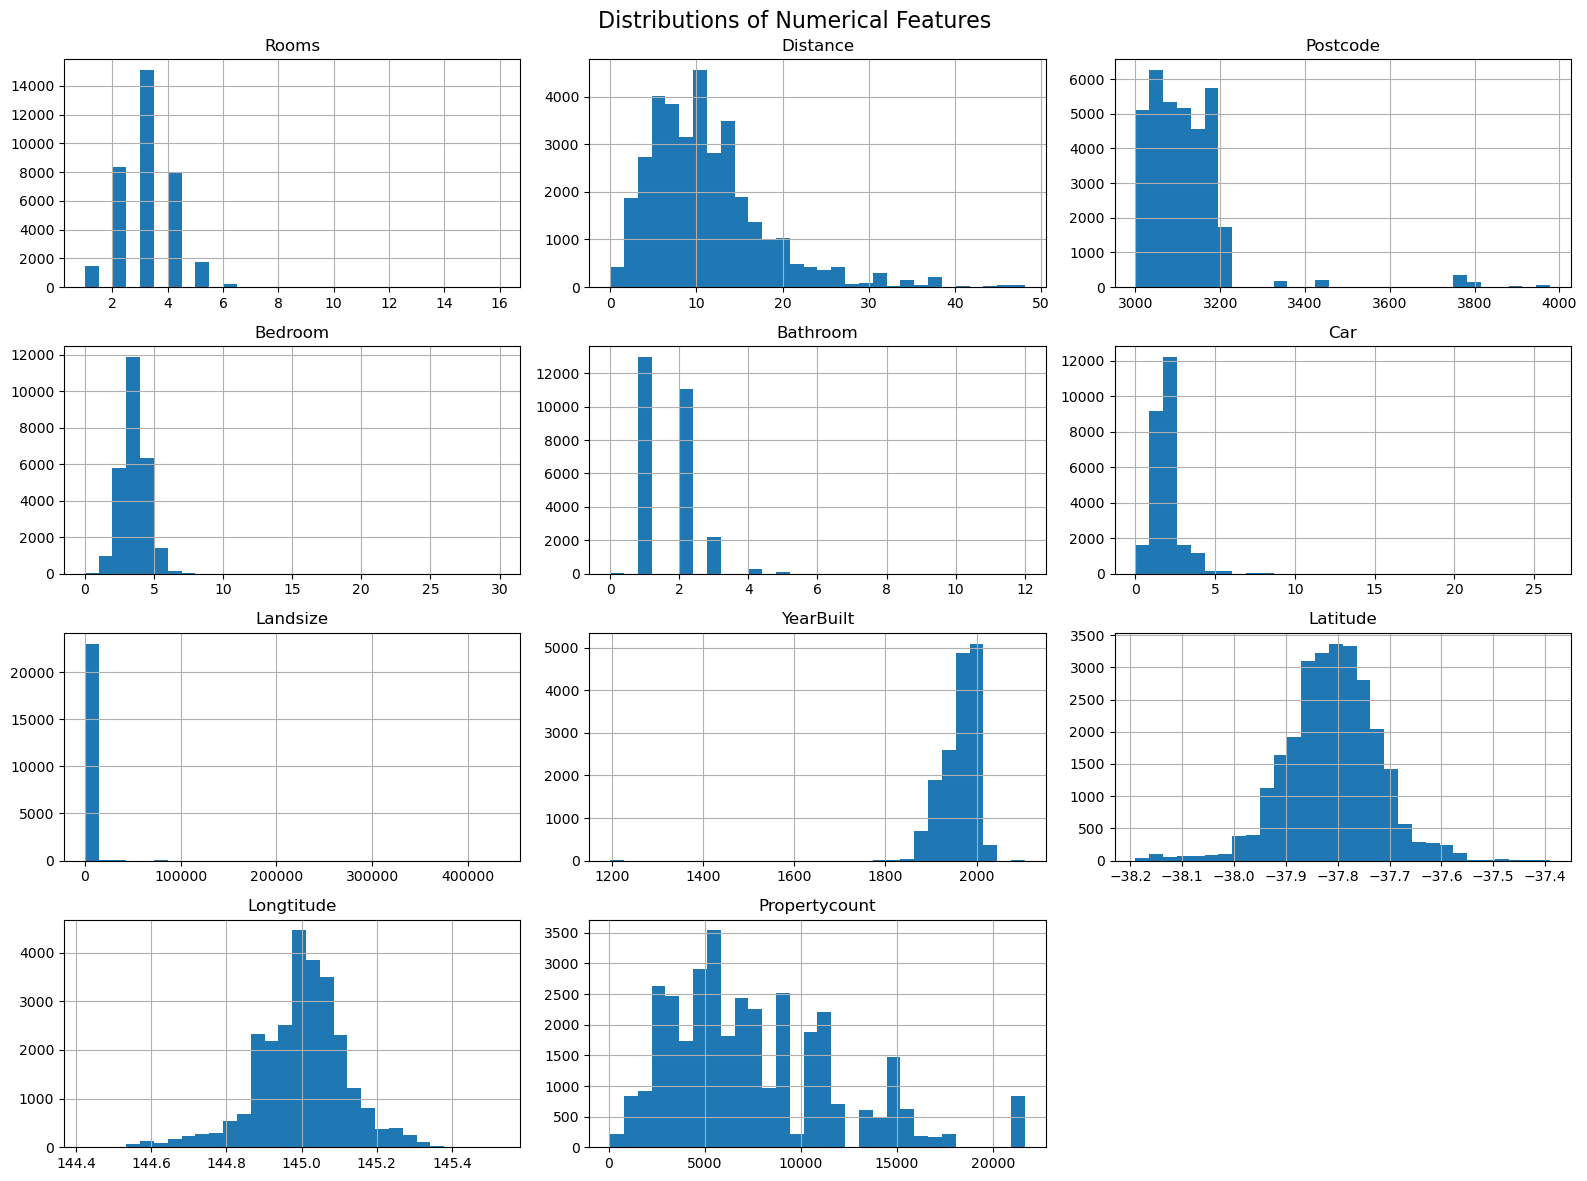

In [386]:
df[numerical_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Insight Analysis

- `Rooms`, `Bedroom`, `Bathroom`, and `Car` are concentrated around relatively small values, reflecting the typical characteristics of residential properties.
- `Distance` is concentrated mainly within the lower range, with fewer properties located substantially farther from the CBD.
- `Landsize` is highly right-skewed, with most properties having relatively small land areas and a small number of extremely large values. 
- `YearBuilt` is concentrated toward more recent construction years, although some unusually old values are present and should be examined for validity.
- `Latitude` and `Longtitude` are relatively concentrated, reflecting the geographic distribution of properties in the dataset.
- `Postcode` shows distinct groups of values rather than a continuous distribution, suggesting that it should be treated carefully during preprocessing rather than interpreted as a conventional continuous numerical feature.

### 2.3 Categorical Feature Distributions

The distributions of categorical variables are examined to understand the composition of the dataset and identify categories with very high or very low frequencies.

In [387]:
categorical_features = df.select_dtypes(include="object").columns

print("Categorical features:")
print(list(categorical_features))

Categorical features:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'BuildingArea', 'CouncilArea', 'Regionname', 'ParkingArea']


In [388]:
categorical_for_eda = [
    "Type",
    "Method",
    "Regionname",
    "ParkingArea"
]

for col in categorical_for_eda:
    print(f"\n{col}:")
    print(df[col].value_counts())


Type:
Type
h    23980
u     7297
t     3580
Name: count, dtype: int64

Method:
Method
S     19744
SP     5095
PI     4850
VB     3108
SN     1317
PN      308
SA      226
W       173
SS       36
Name: count, dtype: int64

Regionname:
Regionname
Southern Metropolitan         11836
Northern Metropolitan          9560
Western Metropolitan           6799
Eastern Metropolitan           4377
South-Eastern Metropolitan     1739
Eastern Victoria                228
Northern Victoria               203
Western Victoria                115
Name: count, dtype: int64

ParkingArea:
ParkingArea
Carport            6243
Detached Garage    6243
Attached Garage    6243
Indoor             5722
Parkade            4682
Underground        2602
Outdoor Stall      2081
Parking Pad        1041
Name: count, dtype: int64


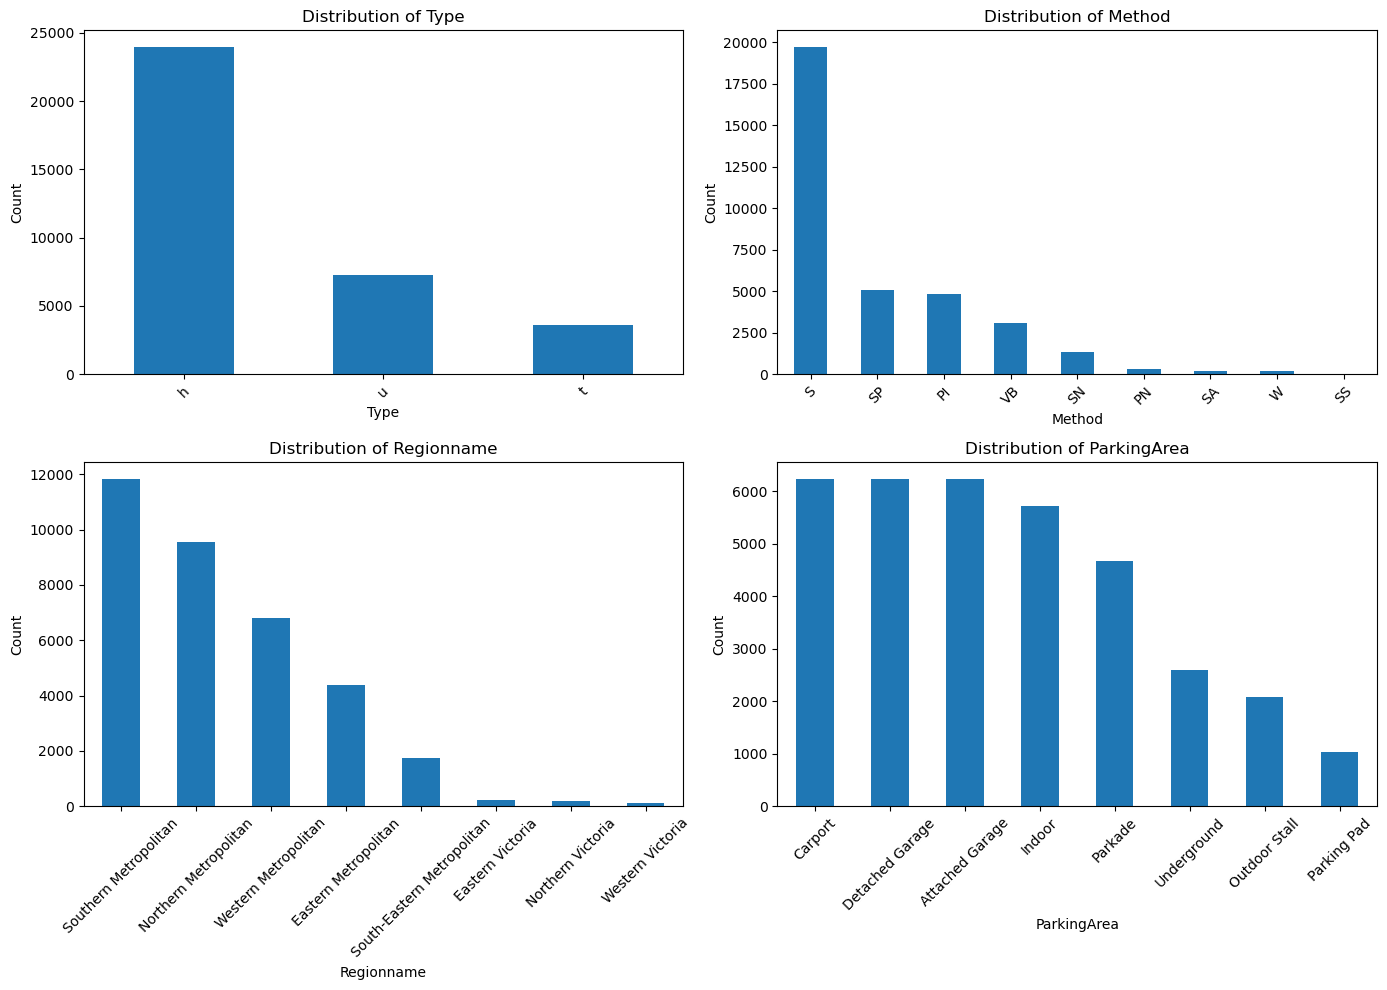

In [389]:
#Since there are a lot of a unique values in a few columns, we will only visualize the distributions of categorical features with a manageable number of unique values.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categorical_for_eda):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Insight Analysis

- The `Type` feature is dominated by the `h` category, indicating that this property type represents the majority of observations in the dataset.
- The `Method` feature is also highly imbalanced, with the `S` category accounting for a large proportion of observations while several other categories occur much less frequently.
- `Regionname` has an uneven distribution, with metropolitan regions contributing substantially more observations than some of the smaller regions.
- `ParkingArea` has a comparatively broader distribution across its categories, although some categories are still more frequent than others.
- The categorical distributions indicate that categorical variables should be encoded appropriately while preserving their information for the regression models.

### 2.4 Correlation Analysis

A correlation matrix is used to examine the linear relationships between numerical variables and identify features that may have stronger relationships with the target variable.

In [390]:
correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)

                  Rooms  Distance  Postcode   Bedroom  Bathroom       Car  \
Rooms          1.000000  0.271511  0.085890  0.946755  0.611826  0.393878   
Distance       0.271511  1.000000  0.481566  0.269524  0.126201  0.241835   
Postcode       0.085890  0.481566  1.000000  0.089292  0.120080  0.067886   
Bedroom        0.946755  0.269524  0.089292  1.000000  0.614892  0.388491   
Bathroom       0.611826  0.126201  0.120080  0.614892  1.000000  0.307518   
Car            0.393878  0.241835  0.067886  0.388491  0.307518  1.000000   
Landsize       0.037402  0.060862  0.040664  0.037019  0.036333  0.037829   
YearBuilt     -0.012749  0.323059  0.089805 -0.002022  0.167955  0.128702   
Latitude       0.004872 -0.100417 -0.231027  0.003447 -0.059183 -0.009020   
Longtitude     0.103235  0.200946  0.362895  0.106164  0.106531  0.047213   
Propertycount -0.071677 -0.018140  0.017108 -0.053451 -0.032887 -0.009617   
Price          0.465238 -0.211384  0.044950  0.430275  0.429878  0.201803   

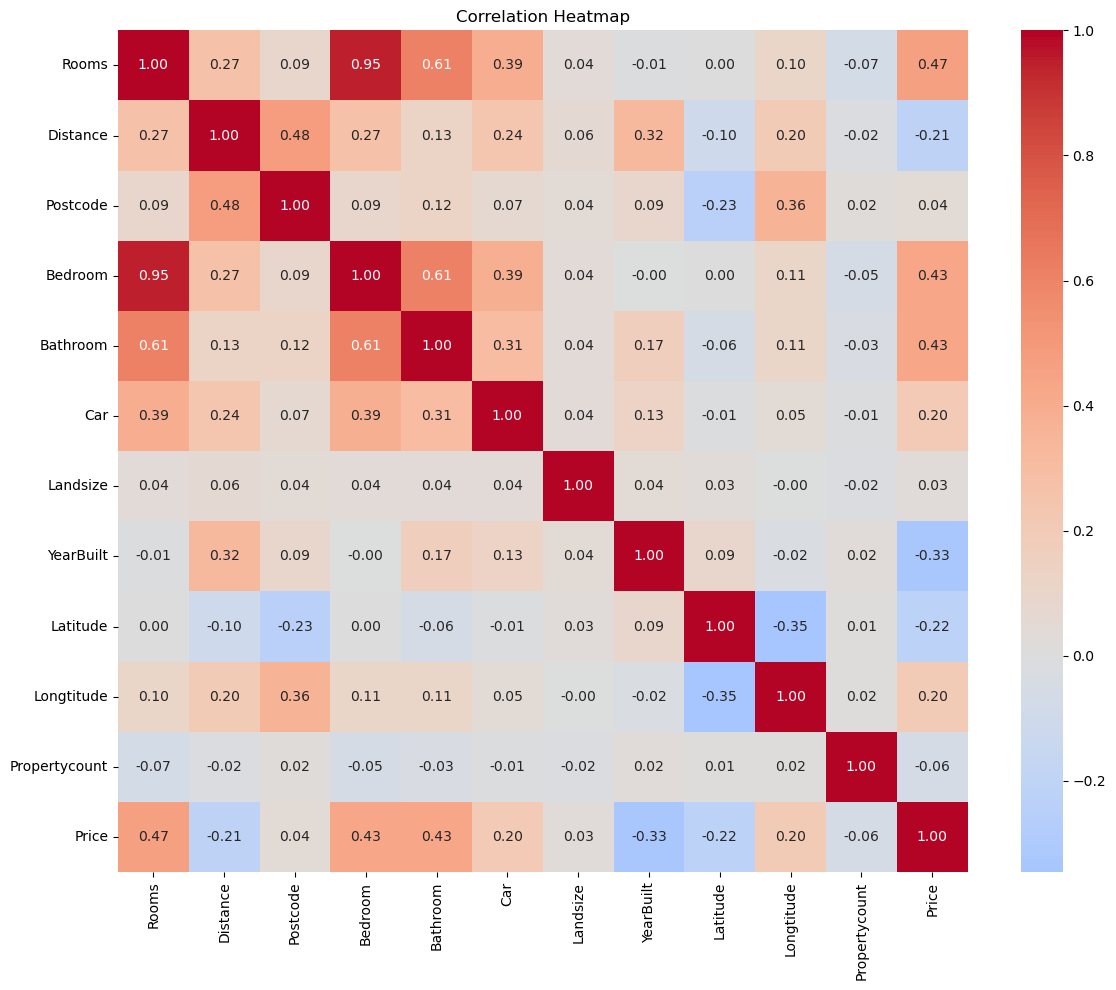

In [391]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Insight Analysis

- `Rooms` has the strongest positive linear correlation with `Price` among the numerical features, with a correlation of approximately 0.47. This indicates that properties with more rooms tend to have higher prices, although the relationship is not strong enough to explain price on its own.
- `Bedroom` and `Bathroom` also show moderate positive correlations with `Price`, both approximately 0.43.
- `Distance` has a moderate negative relationship with `Price` (approximately -0.21), suggesting that properties farther from the CBD tend to have lower prices.
- `YearBuilt` has a negative correlation with `Price` (approximately -0.33). This indicates that newer properties do not necessarily correspond to higher prices in this dataset and that other factors may influence this relationship.
- `Rooms` and `Bedroom` have a very strong correlation of approximately 0.95 with each other, indicating substantial overlap between these two features. This potential multicollinearity will be considered during feature engineering and model development.
- `Landsize` has a very weak linear correlation with `Price` despite its large range, suggesting that its relationship with price may be nonlinear or affected by extreme observations.
- Correlation measures only linear relationships, so features with relatively low correlation should not automatically be considered useless for nonlinear regression models.

### 2.5 Feature vs Target Relationships

Scatter plots are used to examine relationships between selected numerical features and property price.

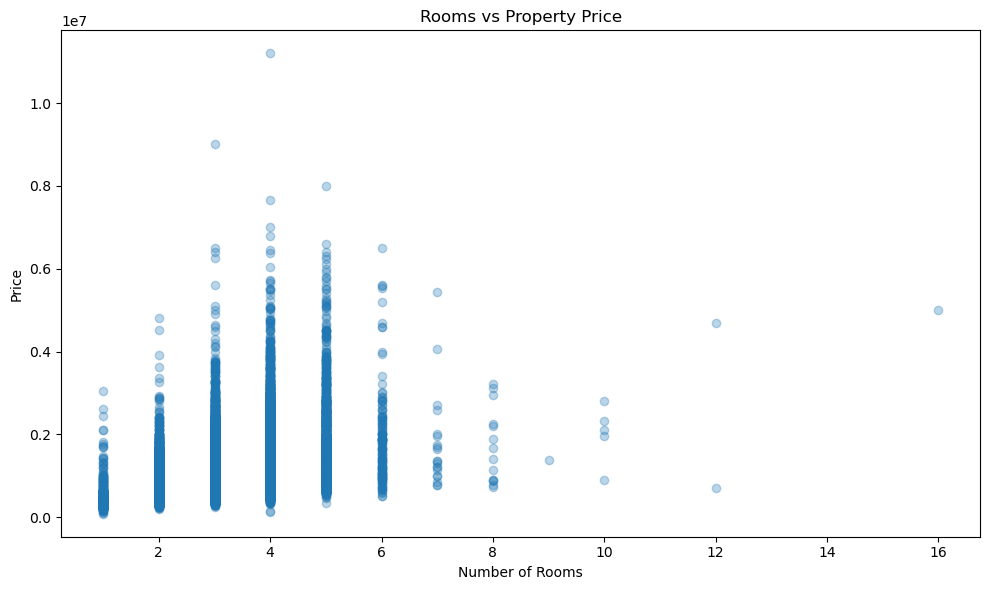

In [392]:
#Scatter plot to show the relationship between rooms and property price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Rooms"],
    df["Price"],
    alpha=0.3
)

plt.title("Rooms vs Property Price")
plt.xlabel("Number of Rooms")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Insight Analysis

There is a generally positive relationship between the number of rooms and property price. Properties with more rooms tend to have higher possible prices, particularly when comparing properties with fewer rooms to those with four or more rooms. However, substantial variation exists within each room category, indicating that room count alone is insufficient to explain property prices. Several high-price observations are also visible and will be investigated during outlier analysis.

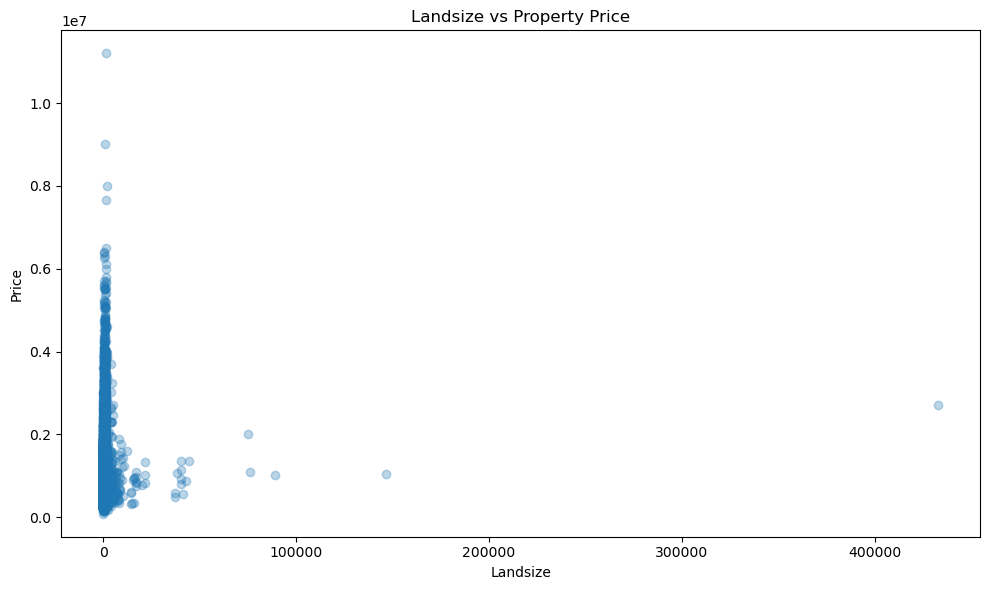

In [393]:
#Scatter plot to show the relationship between landsize and property price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Landsize"],
    df["Price"],
    alpha=0.3
)

plt.title("Landsize vs Property Price")
plt.xlabel("Landsize")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Insight Analysis

The relationship between `Landsize` and `Price` is difficult to observe clearly because the feature is highly right-skewed and contains several extremely large land-area observations. Most properties are concentrated within a relatively small land-area range, while a small number of extreme observations extend far beyond the majority of the data. This indicates that `Landsize` requires further investigation during the outlier and preprocessing stages.

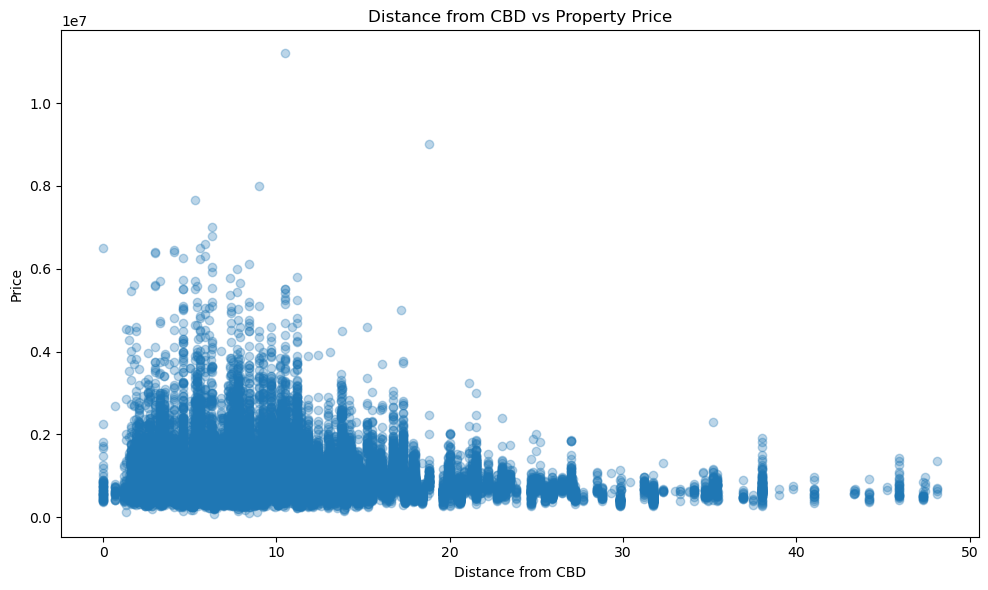

In [394]:
#Scatter plot to show the relationship between distance from CBD and property price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Distance"],
    df["Price"],
    alpha=0.3
)

plt.title("Distance from CBD vs Property Price")
plt.xlabel("Distance from CBD")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Insight Analysis

The scatter plot shows a generally negative relationship between distance from the CBD and property price. Higher-priced properties are more concentrated at lower distances, while properties farther from the CBD tend to have lower price ranges. However, substantial variation remains at most distances, indicating that location is only one of several factors influencing property prices.

## 3. Data Cleaning & Preprocessing

Based on the findings from the dataset audit and exploratory data analysis, the dataset is prepared for machine learning. This stage includes handling missing values, correcting data types, checking outliers, removing unsuitable features, engineering meaningful features, encoding categorical variables, and scaling numerical features where required.

In [395]:
# Create a copy of the original dataset for preprocessing
data = df.copy()

print("Original dataset shape:", data.shape)

Original dataset shape: (34857, 22)


### 3.1 Handling Missing Target Values

Rows with missing values in the target variable, `Price`, cannot be used for supervised regression because there is no known target value against which the model can learn or be evaluated. Therefore, these observations are removed rather than imputing the target.

In [396]:
before = len(data)

data = data.dropna(subset=["Price"]).copy()

after = len(data)

print("Rows before removing missing Price:", before)
print("Rows removed:", before - after)
print("Rows remaining:", after)

Rows before removing missing Price: 34857
Rows removed: 7610
Rows remaining: 27247


### 3.2 Correcting BuildingArea Data Type

`BuildingArea` represents the size of the property's building and should be numerical. The column was originally loaded as an object because it contains mixed values. Non-numeric values are converted to missing values using numeric coercion, after which the resulting missing values will be handled as part of the numerical-feature imputation strategy.

In [397]:
data["BuildingArea"] = pd.to_numeric(
    data["BuildingArea"],
    errors="coerce"
)

print("BuildingArea data type:", data["BuildingArea"].dtype)
print("Missing BuildingArea values:", data["BuildingArea"].isna().sum())

BuildingArea data type: float64
Missing BuildingArea values: 16586


### 3.3 Date Feature Processing

The `Date` column contains the property sale date. It is converted into a datetime representation so that the sale year can be extracted for feature engineering.

The sale year is used as an intermediate variable to calculate the property's age at the time of sale.

In [398]:
data["Date"] = pd.to_datetime(
    data["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

data["SaleYear"] = data["Date"].dt.year

print("Date data type:", data["Date"].dtype)
print("Missing Date values:", data["Date"].isna().sum())
print("Missing SaleYear values:", data["SaleYear"].isna().sum())
print(data[["Date", "SaleYear"]].head())

Date data type: datetime64[ns]
Missing Date values: 0
Missing SaleYear values: 0
        Date  SaleYear
1 2016-09-03      2016
2 2016-09-03      2016
3 2016-09-03      2016
5 2016-09-03      2016
6 2016-09-03      2016


### 3.4 Remaining Missing Values

After removing observations with missing target values and correcting the data type of `BuildingArea`, the remaining missing values are reviewed before selecting appropriate imputation strategies.

In [399]:
missing_after_cleaning = data.isnull().sum()

missing_after_cleaning = (
    missing_after_cleaning[missing_after_cleaning > 0]
    .sort_values(ascending=False)
)

print(missing_after_cleaning)

BuildingArea     16586
YearBuilt        15163
Landsize          9265
Car               6824
Bathroom          6447
Bedroom           6441
Latitude          6254
Longtitude        6254
CouncilArea          3
Propertycount        3
Distance             1
Postcode             1
dtype: int64


### 3.5 Validity Checks

Numerical variables are checked for impossible or potentially invalid values. These checks distinguish genuine extreme observations from values that may represent data-entry or data-quality issues.

In [400]:
checks = {
    "Rooms <= 0": (data["Rooms"] <= 0).sum(),
    "Bedroom < 0": (data["Bedroom"] < 0).sum(),
    "Bathroom < 0": (data["Bathroom"] < 0).sum(),
    "Car < 0": (data["Car"] < 0).sum(),
    "Landsize < 0": (data["Landsize"] < 0).sum(),
    "BuildingArea < 0": (data["BuildingArea"] < 0).sum(),
    "YearBuilt < 1800": (data["YearBuilt"] < 1800).sum(),
    "YearBuilt > 2026": (data["YearBuilt"] > 2026).sum()
}

pd.Series(checks)

Rooms <= 0          0
Bedroom < 0         0
Bathroom < 0        0
Car < 0             0
Landsize < 0        0
BuildingArea < 0    0
YearBuilt < 1800    1
YearBuilt > 2026    0
dtype: int64

In [401]:
# Treat clearly invalid construction years as missing
data.loc[data["YearBuilt"] < 1800, "YearBuilt"] = np.nan

print("Invalid YearBuilt values treated as missing:",
      (data["YearBuilt"].isna()).sum())

Invalid YearBuilt values treated as missing: 15164


### 3.6 Outlier Detection

Potential outliers in numerical features are identified using the Interquartile Range (IQR) method. These observations will be investigated before deciding whether they should be retained, transformed, capped, or removed.

In [402]:
outlier_columns = [
    "Rooms",
    "Bedroom",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Distance",
    "Price"
]

outlier_summary = {}

for col in outlier_columns:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((data[col] < lower) | (data[col] > upper)).sum()

    outlier_summary[col] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    }

outlier_summary = pd.DataFrame(outlier_summary).T

outlier_summary

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
Rooms,2.0,4.0,2.0,-1.0,7.0,23.0
Bedroom,2.0,4.0,2.0,-1.0,7.0,19.0
Bathroom,1.0,2.0,1.0,-0.5,3.5,238.0
Car,1.0,2.0,1.0,-0.5,3.5,1171.0
Landsize,219.0,664.0,445.0,-448.5,1331.5,453.0
BuildingArea,100.0,182.0,82.0,-23.0,305.0,514.0
YearBuilt,1950.0,2000.0,50.0,1875.0,2075.0,27.0
Distance,6.4,14.0,7.6,-5.0,25.4,1188.0
Price,635000.0,1295000.0,660000.0,-355000.0,2285000.0,1278.0


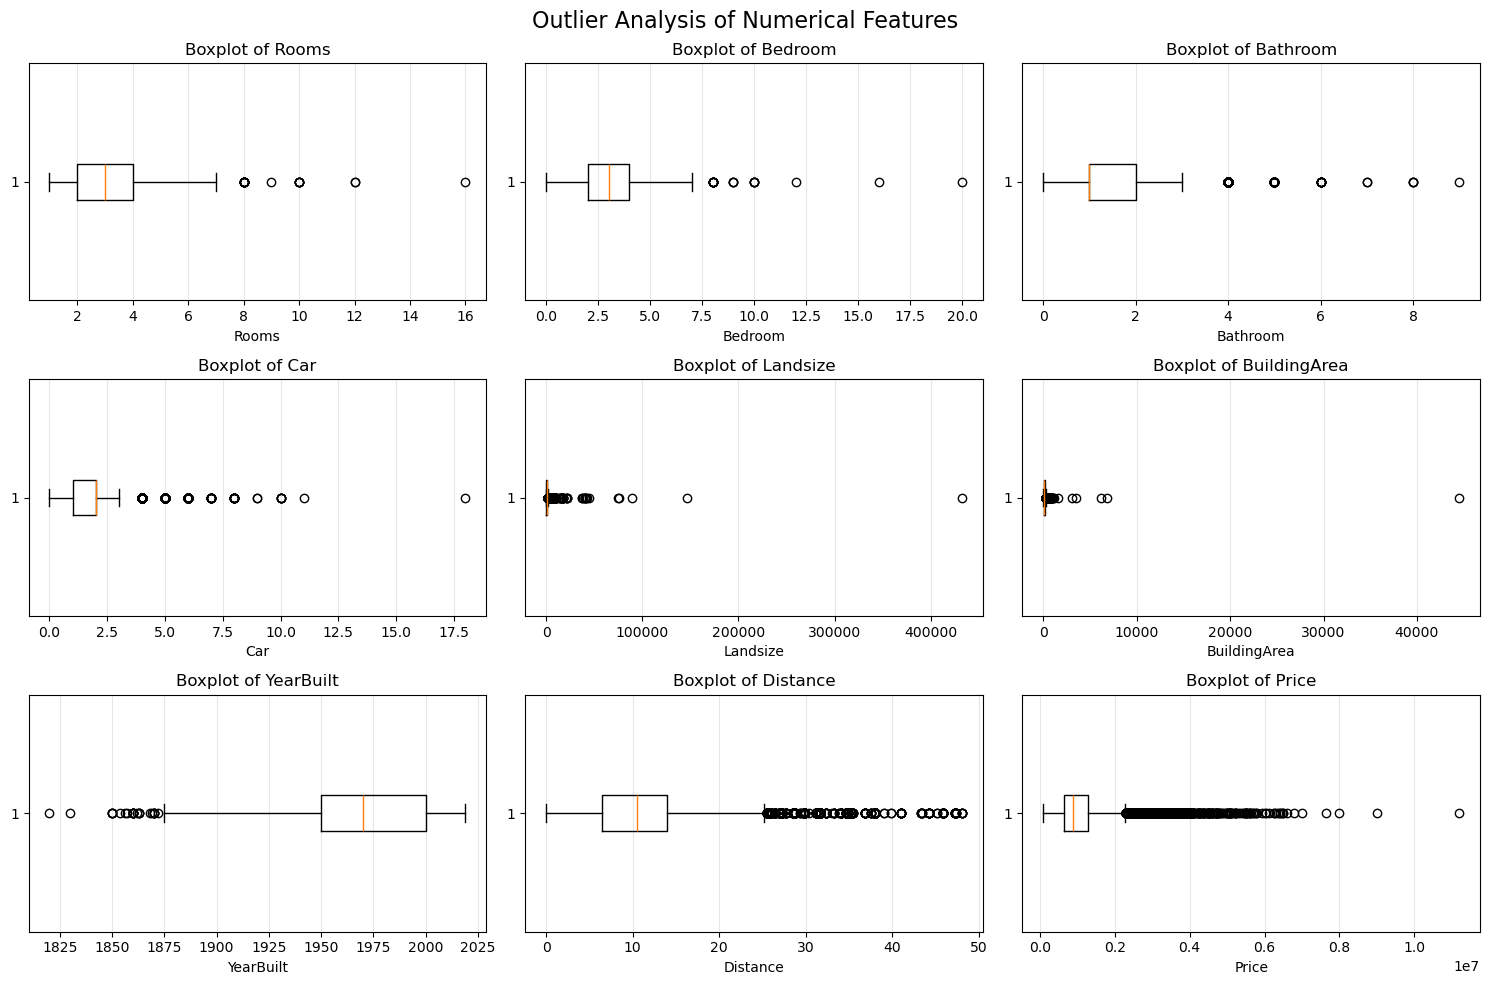

In [403]:
import matplotlib.pyplot as plt

boxplot_columns = [
    "Rooms",
    "Bedroom",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Distance",
    "Price"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.flat, boxplot_columns):
    ax.boxplot(data[col].dropna(), vert=False)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Outlier Analysis of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### 3.7 Feature Engineering

A meaningful domain-based feature is created to capture the age of a property at the time of sale. Property age is calculated as the difference between the sale year and the property's construction year.

In [404]:
data["PropertyAge"] = data["SaleYear"] - data["YearBuilt"]

print(data["PropertyAge"].describe())

print("Missing PropertyAge values:", data["PropertyAge"].isna().sum())

count    12083.000000
mean        50.095672
std         36.029590
min         -2.000000
25%         17.000000
50%         47.000000
75%         68.000000
max        197.000000
Name: PropertyAge, dtype: float64
Missing PropertyAge values: 15164


In [405]:
data.loc[
    data["PropertyAge"] > 150,
    ["Date", "SaleYear", "YearBuilt", "PropertyAge"]
]

,Date,SaleYear,YearBuilt,PropertyAge
100,2016-09-03,2016,1830.0,186.0
636,2016-12-03,2016,1863.0,153.0
1791,2016-05-07,2016,1856.0,160.0
3377,2016-12-10,2016,1860.0,156.0
9630,2017-12-09,2017,1860.0,157.0
10371,2017-11-11,2017,1860.0,157.0
10785,2017-08-12,2017,1862.0,155.0
13882,2016-08-13,2016,1854.0,162.0
15379,2017-07-15,2017,1860.0,157.0
18993,2017-06-17,2017,1863.0,154.0


In [406]:
invalid_age = data[data["PropertyAge"] < 0]

print("Number of negative PropertyAge values:", len(invalid_age))

invalid_age[["Date", "SaleYear", "YearBuilt", "PropertyAge"]]

Number of negative PropertyAge values: 7


,Date,SaleYear,YearBuilt,PropertyAge
352,2016-12-03,2016,2017.0,-1.0
17807,2018-03-17,2018,2019.0,-1.0
19585,2016-09-17,2016,2017.0,-1.0
24997,2016-04-23,2016,2017.0,-1.0
27420,2016-09-24,2016,2018.0,-2.0
32022,2016-05-28,2016,2017.0,-1.0
34817,2016-07-30,2016,2017.0,-1.0


In [407]:
data.loc[
    data["PropertyAge"] < 0,
    ["Date", "SaleYear", "YearBuilt", "PropertyAge"]
]

,Date,SaleYear,YearBuilt,PropertyAge
352,2016-12-03,2016,2017.0,-1.0
17807,2018-03-17,2018,2019.0,-1.0
19585,2016-09-17,2016,2017.0,-1.0
24997,2016-04-23,2016,2017.0,-1.0
27420,2016-09-24,2016,2018.0,-2.0
32022,2016-05-28,2016,2017.0,-1.0
34817,2016-07-30,2016,2017.0,-1.0


In [408]:
data.loc[
    data["PropertyAge"] > 150,
    ["Date", "SaleYear", "YearBuilt", "PropertyAge"]
]

,Date,SaleYear,YearBuilt,PropertyAge
100,2016-09-03,2016,1830.0,186.0
636,2016-12-03,2016,1863.0,153.0
1791,2016-05-07,2016,1856.0,160.0
3377,2016-12-10,2016,1860.0,156.0
9630,2017-12-09,2017,1860.0,157.0
10371,2017-11-11,2017,1860.0,157.0
10785,2017-08-12,2017,1862.0,155.0
13882,2016-08-13,2016,1854.0,162.0
15379,2017-07-15,2017,1860.0,157.0
18993,2017-06-17,2017,1863.0,154.0


In [409]:
# Treat logically invalid negative property ages as missing
data.loc[data["PropertyAge"] < 0, "PropertyAge"] = np.nan

print("Missing PropertyAge values after validity correction:",
      data["PropertyAge"].isna().sum())

Missing PropertyAge values after validity correction: 15171


### 3.8 Handling Date-Derived Features

The original `Date` column was converted to a datetime representation and `SaleYear` was extracted as an intermediate feature for calculating `PropertyAge`.

Since `PropertyAge` captures the relevant temporal information needed for modelling, the original `Date` and intermediate `SaleYear` features are removed from the modelling dataset.

In [410]:
# Remove the original date and highly incomplete date-derived features
data = data.drop(columns=["Date", "SaleYear"])

print("Dataset shape after date feature handling:", data.shape)
print("\nRemaining columns:")
print(data.columns.tolist())

Dataset shape after date feature handling: (27247, 22)

Remaining columns:
['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longtitude', 'Regionname', 'Propertycount', 'ParkingArea', 'Price', 'PropertyAge']


## 4. Train-Test Split and Preprocessing

The cleaned dataset is prepared for machine learning by separating the predictor variables from the target variable. The dataset is then divided into training and testing subsets using an 80:20 split. Preprocessing transformations will be fitted only on the training data to prevent data leakage.

### 4.1 Feature and Target Separation

The cleaned dataset is divided into predictor variables (`X`) and the target variable (`y`). The `Price` column is used as the target for the regression task. The `Address` column is excluded from modelling because of its extremely high cardinality, while other location-related features are retained.

In [411]:
# Replace infinite values with NaN so they can be handled by the imputer
data = data.replace([np.inf, -np.inf], np.nan)

print("Infinite values remaining:")
print(np.isinf(data.select_dtypes(include=np.number)).sum().sum())

Infinite values remaining:
0


In [412]:
# Separate features and target
# Address is excluded because of its extremely high cardinality.
X = data.drop(columns=["Price", "Address"])
y = data["Price"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (27247, 20)
Target shape: (27247,)


### 4.2 Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split. A fixed random state is used to ensure that the split is reproducible. The test set is kept separate from the preprocessing and model-fitting stages and will be used only for final model evaluation.

In [413]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (21797, 20)
Testing set shape: (5450, 20)
Training target shape: (21797,)
Testing target shape: (5450,)


### 4.3 Numerical and Categorical Feature Identification

The predictor variables are separated into numerical and categorical features based on their data types. The `Postcode` feature is treated as categorical because it represents a geographical location identifier rather than a continuous numerical quantity.

In [414]:
# Treat Postcode as a categorical location feature
X_train["Postcode"] = X_train["Postcode"].astype("object")
X_test["Postcode"] = X_test["Postcode"].astype("object")

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Rooms', 'Distance', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount', 'PropertyAge']

Categorical features:
['Suburb', 'Type', 'Method', 'SellerG', 'Postcode', 'CouncilArea', 'Regionname', 'ParkingArea']


### 4.4 Preprocessing Pipeline

Numerical features are processed using median imputation followed by standardization. Categorical features are processed using most-frequent imputation followed by one-hot encoding. The preprocessing steps are implemented using a pipeline so that all transformations are fitted only on the training data, preventing data leakage.

In [415]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 4.5 Combined Preprocessing

The numerical and categorical preprocessing pipelines are combined using a `ColumnTransformer`. This allows the appropriate transformations to be applied to each group of features while maintaining a consistent preprocessing structure for the regression models.

In [416]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

### 4.6 Combined Preprocessing Pipeline

The numerical and categorical preprocessing steps are combined using a `ColumnTransformer`. The complete preprocessing structure is fitted only on the training data and subsequently used to transform both the training and testing sets. This ensures that information from the testing set does not influence the learned preprocessing parameters, thereby preventing data leakage.

In [417]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

### 4.7 Fit and Transform the Data

The preprocessing transformer is fitted only on the training data. The learned transformations are then applied to both the training and testing sets. This ensures that information from the testing set does not influence imputation, scaling, or categorical encoding, thereby preventing data leakage.

In [418]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (21797, 954)
Processed testing shape: (5450, 954)


### 4.8 Verification of Preprocessed Data

The preprocessing pipeline is fitted using only the training data and then applied to both the training and testing sets. The transformed datasets are checked to ensure that they have the same feature dimensions and contain no missing or infinite values.

In [420]:
from scipy import sparse

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

if sparse.issparse(X_train_processed):
    print("Processed training data is sparse:", True)
    print("Processed testing data is sparse:", True)
    
    print(
        "Non-finite values in training data:",
        np.isfinite(X_train_processed.data).sum()
        != X_train_processed.data.size
    )
    
    print(
        "Non-finite values in testing data:",
        np.isfinite(X_test_processed.data).sum()
        != X_test_processed.data.size
    )
else:
    print("Processed training data is sparse:", False)
    print("Processed testing data is sparse:", False)
    
    print(
        "Non-finite values in training data:",
        np.isfinite(X_train_processed).sum()
        != X_train_processed.size
    )
    
    print(
        "Non-finite values in testing data:",
        np.isfinite(X_test_processed).sum()
        != X_test_processed.size
    )

Processed training shape: (21797, 954)
Processed testing shape: (5450, 954)
Processed training data is sparse: True
Processed testing data is sparse: True
Non-finite values in training data: False
Non-finite values in testing data: False
